## Машинное обучение 1, ПМИ ФКН ВШЭ

## Практическое домашнее задание 1

### Общая информация

Дата выдачи: 25.09.2024

Мягкий дедлайн: 23:59MSK 06.10.2024

Жесткий дедлайн: 23:59MSK 10.10.2024

### О задании

Задание состоит из двух разделов, посвященных работе с табличными данными с помощью библиотеки `polars` и визуализации с помощью `matplotlib`. В первом разделе вам предстоит выполнить базовые задания с помощью вышеуказанных библиотек, а во втором распределить студентов по курсам. Баллы даются за выполнение отдельных пунктов. Задачи в рамках одного раздела рекомендуется решать в том порядке, в котором они даны в задании.

Задание направлено на освоение jupyter notebook (будет использоваться в дальнейших заданиях), библиотек polars и matplotlib.

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов без учёта бонусов. Сдавать задание после жёсткого дедлайна нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно получить у семинариста или ассистента. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате `homework-practice-01-polars-Username.ipynb`, где Username — ваша фамилия.

Для удобства проверки самостоятельно посчитайте свою максимальную оценку (исходя из набора решенных задач) и укажите ниже.

Оценка: 13 (я сделала все + бонус за polars)

## 0. Введение

Сейчас мы находимся в jupyter-ноутбуке (или ipython-ноутбуке). Это удобная среда для написания кода, проведения экспериментов, изучения данных, построения визуализаций и других нужд, не связанных с написанием production-кода.

Ноутбук состоит из ячеек, каждая из которых может быть либо ячейкой с кодом, либо ячейкой с текстом размеченным и неразмеченным. Текст поддерживает markdown-разметку и формулы в Latex.

Для работы с содержимым ячейки используется *режим редактирования* (*Edit mode*, включается нажатием клавиши **Enter** после выбора ячейки), а для навигации между ячейками искользуется *командный режим* (*Command mode*, включается нажатием клавиши **Esc**). Тип ячейки можно задать в командном режиме либо с помощью горячих клавиш (**y** to code, **m** to markdown, **r** to edit raw text), либо в меню *Cell -> Cell type*.

После заполнения ячейки нужно нажать *Shift + Enter*, эта команда обработает содержимое ячейки: проинтерпретирует код или сверстает размеченный текст.

In [1]:
# ячейка с кодом, при выполнении которой появится output
2 + 2

4

Ячейка с неразмеченыным текстом.

Попробуйте создать свои ячейки, написать какой-нибудь код и текст какой-нибудь формулой.

In [2]:
# your code
print('grass'[:3] + 'сias')

graсias


[Здесь](https://athena.brynmawr.edu/jupyter/hub/dblank/public/Jupyter%20Notebook%20Users%20Manual.ipynb) находится <s>не</s>большая заметка о используемом языке разметки Markdown. Он позволяет:

0. Составлять упорядоченные списки
1. Выделять *текст* <s>при</s> **необходимости**
2. Добавлять [ссылки](http://imgs.xkcd.com/comics/the_universal_label.png)


* Составлять неупорядоченные списки

Делать вставки с помощью LaTex:
    
$
\left\{
\begin{array}{ll}
x = 16 \sin^3 (t) \\
y = 13 \cos (t) - 5 \cos (2t) - 2 \cos (3t) - \cos (4t) \\
t \in [0, 2 \pi]
\end{array}
\right.$

А ещё можно вставлять картинки, или гифки, или что захотите:

<img src="https://i.imgur.com/k5df8lX.gif" width="400px">



### Google Colab

Что за колаб?

**Google Colab (Colaboratory)** это **Jupyter Notebook + Cloud + Google Drive.**

Компания Google предоставляет возможность бесплатно запускать ноутбуки (предварительно загрузив их на свой гугл-диск) прямо в облаке. При этом вам не требуется установка никаких пакетов на свою машину, а работать можно прямиком из браузера. Вот ссылка:

https://colab.research.google.com

При использовании вы увидите много сходств с jupyter ноутбуком. Одним из преимуществ является доступность GPU, соответствующую опцию можно активировать в настройках сервиса. При желании вы сможете найти в интернете много туториалов по использованию или разобраться самостоятельно =)

### Kaggle

Альтернативой является **Kaggle**, он же площадка для самых разных соревнований по машинному обучению

Он, как и колаб, предоставляет бесплатный GPU, и даже не один, с чётким лимитом в 30 часов в неделю (colab может его внезапно отобрать, kaggle - нет) более мощные CPU с большим числом ядер, и больше Гб ОЗУ (раз так в 2.5)

https://www.kaggle.com

К сожалению мир не идеален, недостатки следующие:
- необходимость загружать датасеты через специальную кнопочку
- невозможность использовать свои скрипты и модули :(
- нужно тыкать техподдержку, чтобы создать аккаунт из России

## 1. Табличные данные и Polars

Эта версия домашки предполагает, что вы уже являетесь уверенным пользователем `pandas` и знакомы с датафреймами, как они устроены и как ими манипулировать. Библиотека `polars` основана на тех же концептах.

Главные достоинства, которые чуть позже продемонстрируем:
- он написан на Rust, поэтому почти все операции в нём выполняются значительно быстрее, есть распараллеливание из коробки, автоматическая оптимизация запросов и пр
- он позволяет работать с данными, которые не помещаются в оперативку, с этим поможет `pl.LazyFrame` и streaming
- конечно же имеются дополнительные функции, которых в `pandas` нет, но очень хочется, например агрегации с расширяющимся окном, произвольные оконные функции и прочее, для этого есть крайне гибкая штука `pl.Expr`

Подробнее можете прочитать на [любом](https://habr.com/ru/articles/710240/) [ресурсе](https://realpython.com/polars-python/), [посвящённом](https://blog.jetbrains.com/pycharm/2024/07/polars-vs-pandas/) [`polars`](https://habr.com/ru/companies/spectr/articles/738766/)

В этой части потребуется выполнить несколько небольших заданий. Можно пойти двумя путями: сначала изучить материалы, а потом приступить к заданиям, или же разбираться "по ходу". Выбирайте сами

Если не понятно, как вызывать конкретный метод, обратитесь к материалам ниже. Имейте в виду, что синтаксис `polars` отличается от привычного нампаевского.
Скорее всего все ваши самые извращённые фантазии уже как-то реализованы в `polars`, поэтому читайте внимательно. Ну и конечно гуглить не запрещено, но желательно прикладывать источник

Материалы:
1. [Getting started](https://docs.pola.rs/user-guide/getting-started/#reading-writing) из официального руководства
2. [Документация](https://docs.pola.rs/api/python/stable/reference/index.html) со всем необходимым
3. [Модификация для Data Science](https://polars-ds-extension.readthedocs.io/en/latest/index.html), вам скорее всего не понадобится в данном задании, но имейте в виду

Многие из заданий можно выполнить несколькими способами. Не существуют единственно верного, но попробуйте максимально задействовать арсенал polars и ориентируйтесь на простоту и понятность вашего кода. Мы не будем подсказывать, что нужно использовать для решения конкретной задачи, попробуйте находить необходимый функционал сами (название метода чаще всего очевидно)

In [3]:
# поларс относительно молодой, имейте в виду, что что-то может сломаться, если будете менять версию
# почему-то указанная версия грохала kernel при импорте polars, stackoverflow сказал сделать так
!pip install polars-lts-cpu

  Using cached polars_lts_cpu-1.9.0-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (14 kB)
Using cached polars_lts_cpu-1.9.0-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (32.6 MB)


In [4]:
import polars as pl

In [5]:
pip install fastexcel

  Using cached fastexcel-0.11.6-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.8 kB)
Using cached fastexcel-0.11.6-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (1.2 MB)
Note: you may need to restart the kernel to use updated packages.


Скачаем данные:

In [6]:
df = pl.read_excel('_end_seminar.xlsx')

In [7]:
df_help = pl.read_excel('_end_seminar.xlsx')

In [8]:
df

timestamp,id,rating,18_group,is_mi,fall_1,fall_2,fall_3,spring_1,spring_2,spring_3,is_first_time,percentile,17_group,blended,is_ml_student
datetime[ms],str,i64,i64,i64,str,str,str,str,str,str,str,f64,null,null,bool
2020-05-15 01:12:50.543,"""93ff79a51cd602f1dd3028ba2c1295…",698,181,null,"""Язык SQL""","""Высокопроизводительные вычисле…","""Матричные вычисления""","""Дискретная оптимизация""","""Численные методы""","""Машинное обучение 2""","""Да""",0.183857,null,null,null
2020-05-15 02:46:48.066,"""26b01b1c4cd5656bab18d24c548834…",647,181,null,"""Высокопроизводительные вычисле…","""Безопасность компьютерных сист…","""Язык SQL""","""Дискретная оптимизация""","""Численные методы""","""Машинное обучение 2""","""Нет""",0.426009,null,null,null
2020-05-15 03:12:41.480,"""30f3653fc176d54e89ac3179c455c6…",624,185,null,"""Безопасность компьютерных сист…","""Матричные вычисления""","""Моделирование временных рядов""","""Дискретная оптимизация""","""Машинное обучение 2""","""Численные методы""","""Да""",0.538117,null,null,null
2020-05-15 04:43:08.994,"""1528f0eaa027580820ccf0d92a53ad…",579,182,null,"""Statistical Learning Theory""","""Высокопроизводительные вычисле…","""Матричные вычисления""","""Дискретная оптимизация""","""Численные методы""","""Машинное обучение 2""","""Да""",0.744395,null,null,null
2020-05-15 07:47:17.197,"""496ea4f0d4abe264b1bb1b80eb3830…",572,183,null,"""Высокопроизводительные вычисле…","""Безопасность компьютерных сист…","""Теория баз данных""","""Компьютерные сети""","""Дискретная оптимизация""","""Численные методы""","""Да""",0.780269,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2020-05-19 19:04:17.873,"""c5870b37ee3f672e4259dfb2fc02ed…",1029,null,null,"""Statistical Learning Theory""","""Анализ неструктурированных дан…","""Сбор и обработка данных с помо…","""Обучение с подкреплением""","""Конфликты и кооперация""","""Компьютерное зрение""","""Да""",0.92029,null,null,null
2020-05-19 20:19:25.815,"""f44aea1095f9f5b8e2f5f0ed2b1789…",1060,null,null,"""Анализ неструктурированных дан…","""Высокопроизводительные вычисле…","""Моделирование временных рядов""","""Конфликты и кооперация""","""Обучение с подкреплением""","""Численные методы""","""Да""",0.84058,null,null,null
2020-05-20 11:54:38.318,"""d7118b44c7e8fdbbaaca226d2da6fe…",1111,null,null,"""Сбор и обработка данных с помо…","""Statistical Learning Theory""","""Анализ неструктурированных дан…","""Проектирование и разработка вы…","""Методы сжатия и передачи медиа…","""Численные методы""","""Да""",0.652174,null,null,null


### 📌 **Обязательно прочитайте блок ниже**

> Пандасом и нампаем пользоваться неельзяя... Совсем

> В первой части задания (до раздела "Распределение студентов по курсам") использование циклов запрещается и повлечет за собой снижение оценки. Во второй уже можно, но с оговорками, о чём ниже

> Циклами в данном случае считается `for`, `while` и map-методы `polars`, где можно использовать лямбда-функцию. Главным образом `map_elements` и его производные.
И как правило, всё то, что не умеет делать `pl.LazyFrame` - список [здесь](https://docs.pola.rs/api/python/stable/reference/lazyframe/index.html). Мотивация следующая - используя встроенные функции и методы, `polars` может оптимизировать ваш запрос и провести все нужные манипуляции, прежде чем сериализовать и вывести ответ (за некоторыми исключениями), поэтому важно научиться с этим управляться

> Чтобы сделать выбор `polars` осмысленным, мы немножко модифицируем исходный датасет. Он будет больше в несколько раз и может не влезть в память, если у вас меньше 8 Гб, а с учётом преобразований может потребоваться до 64 Гб! Не пренебрегайте возможностями `pl.LazyFrame`. Его использование не обязательно, но может сильно облегчить вам жизнь

> Трансформировать датасет `df` можно, как только это потребуется по условию (таких пунктов всего 2), на всякий случай поставим значок 🔄

> Если небрежно обращаться с методами `polars`, вы рискуете крашнуть ядро, взорвать компутер, потерять рассудок... Если вдруг у вас есть тачка или хотите подебажить на исходном датасете, то пожалуйста, но помните про условия выше

> Гарантируется, что задание можно выполнить, имея лишь ресурсы Google Colab (бесплатные), удачи ( ͡° ͜ʖ ͡°)

Для каждой задачи из этого раздела вы должны написать код для получения ответа, а также дать текстовый ответ, если он предполагается.

На некоторые вопросы вы можете получить путём пристального взгляда на таблицу, но это не будет засчитываться. Вы в любом случае должны получить ответ с помощью кода.

### 🐻 Бонус polars. [3 балла]
Бонус за использование `polars` равен вашей оценке за дз, умноженной на коэффициент 1.3, поэтому даже если сделали не всё, не отчаивайтесь)

#### 0. Ещё пара красивых слов

Первые несколько манипуляций мы сделаем за вас, а заодно поясним, в чём тут нюанс

In [9]:
pip install xlsx2csv

  Using cached xlsx2csv-0.8.3-py3-none-any.whl.metadata (5.7 kB)
Using cached xlsx2csv-0.8.3-py3-none-any.whl (15 kB)
Note: you may need to restart the kernel to use updated packages.


In [10]:
# читаем датафрейм
initial_df = pl.read_excel("_end_seminar.xlsx", engine="xlsx2csv")
print(initial_df.shape[0], "rows")
print(initial_df.estimated_size("mb"), "mb")

361 rows
0.14587879180908203 mb


Как видим, он достаточно маленький. С такими объёмами выбор библиотеки это чисто вкусовщина. Давайте немного поднимем ставки

In [11]:
def repeat_df(df: pl.DataFrame | pl.LazyFrame, n: int = 2) -> pl.LazyFrame:
    return (
        df.lazy()
        .select(pl.col("timestamp").unique().sort().repeat_by(n).flatten())
        .join(df.lazy(), on="timestamp", how="left")
    )

In [12]:
# Проверю на тестовом датафрейме работу функции
df_check = df[1:4, :4]
df_check

timestamp,id,rating,18_group
datetime[ms],str,i64,i64
2020-05-15 02:46:48.066,"""26b01b1c4cd5656bab18d24c548834…",647,181
2020-05-15 03:12:41.480,"""30f3653fc176d54e89ac3179c455c6…",624,185
2020-05-15 04:43:08.994,"""1528f0eaa027580820ccf0d92a53ad…",579,182


In [13]:
g = repeat_df(df_check, 2)
g.collect()

timestamp,id,rating,18_group
datetime[ms],str,i64,i64
2020-05-15 02:46:48.066,"""26b01b1c4cd5656bab18d24c548834…",647,181
2020-05-15 02:46:48.066,"""26b01b1c4cd5656bab18d24c548834…",647,181
2020-05-15 03:12:41.480,"""30f3653fc176d54e89ac3179c455c6…",624,185
2020-05-15 03:12:41.480,"""30f3653fc176d54e89ac3179c455c6…",624,185
2020-05-15 04:43:08.994,"""1528f0eaa027580820ccf0d92a53ad…",579,182
2020-05-15 04:43:08.994,"""1528f0eaa027580820ccf0d92a53ad…",579,182


In [14]:
# проверим повторы
df.filter(~df["timestamp"].is_unique())

timestamp,id,rating,18_group,is_mi,fall_1,fall_2,fall_3,spring_1,spring_2,spring_3,is_first_time,percentile,17_group,blended,is_ml_student
datetime[ms],str,i64,i64,i64,str,str,str,str,str,str,str,f64,null,null,bool
2020-05-23 21:16:40.916,"""79d14db48e4737af731960ae212d51…",966,null,null,"""Безопасность компьютерных сист…","""Принятие решений в условиях ри…","""Анализ неструктурированных дан…","""Проектирование и разработка вы…","""Методы сжатия и передачи медиа…","""Компьютерное зрение""","""Да""",0.985507,null,null,null
2020-05-23 21:16:40.916,"""f2d210ace25a841e1e58036b257d5d…",1195,null,null,"""Анализ неструктурированных дан…","""Моделирование временных рядов""","""Высокопроизводительные вычисле…","""Обучение с подкреплением""","""Компьютерное зрение""","""Методы сжатия и передачи медиа…",null,0.369565,null,null,null


Для работы с датафреймами, которые в память не влезают, нам понадобится объект `pl.LazyFrame`. Он представляет из себя схему выполнения вашего запроса, который оптимизируется, бьётся на батчи и параллелится под капотом через StreamingAPI, что для нас просто идеально. Перевести объект туда можно через метод `lazy`, обратно через `collect`. Учтите, что `streaming=True` работает не со всеми операциями, применяйте с умом, это можно проверить через `pl.LazyFrame.explain(streaming=True)`

In [15]:
repeat_n = 2

repeated_df = repeat_df(initial_df, repeat_n)
print("Schema")
print(repeated_df.explain(streaming=True, optimized=True))

Schema
LEFT JOIN:
LEFT PLAN ON: [col("timestamp")]
   SELECT [col("timestamp").unique().sort(asc).repeat_by([dyn int: 2]).explode()] FROM
    STREAMING:
      DF ["timestamp", "id", "rating", "18_group"]; PROJECT 1/16 COLUMNS; SELECTION: None
RIGHT PLAN ON: [col("timestamp")]
  DF ["timestamp", "id", "rating", "18_group"]; PROJECT */16 COLUMNS; SELECTION: None
END LEFT JOIN


In [16]:
# как видим, повторы работают
repeated_df = repeated_df.collect()
assert repeated_df.shape[0] == initial_df.shape[0] * repeat_n
print(repeated_df.shape[0], "rows")
print(repeated_df.estimated_size("mb"), "mb")

722 rows
0.2917900085449219 mb


Теперь ещё интереснее. Если бы наш датасет был не в 2 раза больше, а в 100000 раз, что бы мы делали? К счастью для нас, поларс может уместить 300кк строк всего лишь в 512Мб, и это даже не прикол, но работать с этим придётся немного иначе

In [17]:
N = 100000

df = repeat_df(initial_df, N)
print(initial_df.estimated_size("gb") * N, "gb")

14.245975762605667 gb


Поэтому даже такая тривиальная задача, как подсчёт строк становится уже не такой простой. Про это и будет дз

In [18]:
try:
    print(df.shape[0], "rows")
except AttributeError:
    print("ой, не получилось...")

# df.collect().shape[0] # тоже можно, если влезет
# len(df.collect().to_pandas()) # а такое может крашнуть ядро, попробуйте, хехе...

ой, не получилось...


In [19]:
def lazy_len(df: pl.LazyFrame) -> int:
    return df.select(pl.len()).collect().item()


rows = lazy_len(df)  # намного экономнее, потому что оптимизировано под капотом
assert rows == initial_df.shape[0] * N
print(rows, "rows")

36100000 rows


#### 1. [0.5 баллов] Откройте файл с таблицей (не забудьте про её формат). Выведите 3 последних строки

Посмотрите на данные и скажите, что они из себя представляют, сколько в таблице строк, какие столбцы? (на это не надо отвечать, просто подумайте об этом)

In [20]:
# 3 последние строки
df.tail(3).collect()

timestamp,id,rating,18_group,is_mi,fall_1,fall_2,fall_3,spring_1,spring_2,spring_3,is_first_time,percentile,17_group,blended,is_ml_student
str,str,i64,i64,i64,str,str,str,str,str,str,str,f64,str,str,bool
"""2020-05-24 01:23:31""","""9d19b0d5f4fc8d7edc2258406f872c…",695,188,null,"""Безопасность компьютерных сист…","""Язык SQL""","""Высокопроизводительные вычисле…","""Компьютерные сети""","""Дискретная оптимизация""","""Численные методы""",null,0.197309,null,null,null
"""2020-05-24 01:23:31""","""9d19b0d5f4fc8d7edc2258406f872c…",695,188,null,"""Безопасность компьютерных сист…","""Язык SQL""","""Высокопроизводительные вычисле…","""Компьютерные сети""","""Дискретная оптимизация""","""Численные методы""",null,0.197309,null,null,null
"""2020-05-24 01:23:31""","""9d19b0d5f4fc8d7edc2258406f872c…",695,188,null,"""Безопасность компьютерных сист…","""Язык SQL""","""Высокопроизводительные вычисле…","""Компьютерные сети""","""Дискретная оптимизация""","""Численные методы""",null,0.197309,null,null,null


<a href="https://ibb.org.ru/1/fPIN9F"><img src="https://ibb.org.ru/images/2024/10/07/i-am-looking-.jpg" alt="i-am-looking-.jpg" border="0"></a>

In [21]:
# Количесто строк и столбцов

print(f'Число строк: {lazy_len(df)}')
print(f'Число столбцов: {len(df.collect_schema().names())}')

Число строк: 36100000
Число столбцов: 16


In [22]:
# Посмотрим на столбцы и их типа данных
# Заметим, что инфа о группах 18 и 17 годов набора имеют разный тип данных

df.collect_schema()

Schema([('timestamp', String),
        ('id', String),
        ('rating', Int64),
        ('18_group', Int64),
        ('is_mi', Int64),
        ('fall_1', String),
        ('fall_2', String),
        ('fall_3', String),
        ('spring_1', String),
        ('spring_2', String),
        ('spring_3', String),
        ('is_first_time', String),
        ('percentile', Float64),
        ('17_group', String),
        ('blended', String),
        ('is_ml_student', Boolean)])

### Ответьте на вопросы:
1. Сколько было уникальных пользователей из групп 18-го года набора, а сколько из групп 17-го года?

In [23]:
# Число уникальных студентов по группам 18 года набора
unique_18 = df.group_by('18_group').agg(pl.col('id').unique().count()).filter(~pl.col('18_group').is_null()).collect()
unique_18

18_group,id
i64,u32
186,27
183,31
188,23
182,26
185,28
181,27
187,30
184,21


In [24]:
# Общее число уникальных студентов для 18 года
unique_18.filter(~pl.col('18_group').is_null()).select(pl.col('id')).sum()

id
u32
213


In [25]:
# Число уникальных студентов по группам 17 года набора
unique_17 = df.group_by('17_group').agg(pl.col('id').unique().count()).filter(~pl.col('17_group').is_null()).collect()
unique_17

17_group,id
str,u32
"""176""",17
"""171""",26
"""174""",15
"""177""",3
"""175""",26
"""173""",19
"""172""",28


In [26]:
# Общее число уникальных студентов для 17 года
unique_17.filter(~pl.col('17_group').is_null()).select(pl.col('id')).sum()

id
u32
134


2. Есть ли уникальные студенты с равными перцентилями?

In [27]:
# Такие студенты есть
df.group_by('id').agg(pl.col('percentile').unique()).explode("percentile").filter(pl.col('percentile').is_duplicated()).collect()

id,percentile
str,f64
"""3e106aaef8b24dbb01319c73e14c29…",0.0
"""3a7326c9e355a67d3805824ca34c4b…",0.0


#### 2. [0.5 балла] Есть ли в данных пропуски? В каких колонках? Сколько их в каждой из этих колонок?

Уникальных или нет - не столь важно

In [28]:
df.select(pl.all().is_null().sum()).collect()

timestamp,id,rating,18_group,is_mi,fall_1,fall_2,fall_3,spring_1,spring_2,spring_3,is_first_time,percentile,17_group,blended,is_ml_student
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,13800000,34300000,0,0,0,0,0,0,200000,0,22300000,22300000,30400000


🔄 Преобразуйте датасет - заполните пропуски пустой строкой для строковых колонок, нулём для числовых и False для булевых (постарайтесь избежать перечисления названий всех столбцов).

In [29]:
df = df.select([
    pl.col(pl.String).fill_null('')
    , pl.col(pl.Int64).fill_null(0)
    , pl.col(pl.Float64).fill_null(0)
    , pl.col(pl.Boolean).fill_null(False)
]).collect().lazy()

In [30]:
df.select(pl.all().is_null().sum()).collect()

timestamp,id,fall_1,fall_2,fall_3,spring_1,spring_2,spring_3,is_first_time,17_group,blended,rating,18_group,is_mi,percentile,is_ml_student
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


#### 3. [0.5 балла] Посмотрите повнимательнее на колонку 'is_first_time'.

Каково процентное соотношение ответов? Сколько из них "Нет"?

In [31]:
answers_counts = df.select([
                            pl.col('is_first_time')
]).collect()['is_first_time'].value_counts()
answers_counts

is_first_time,count
str,u32
"""Нет""",5100000
"""Да""",30800000
"""""",200000


In [32]:
# Процентное соотношение

said_no = (answers_counts.filter(pl.col('is_first_time') == 'Нет')['count'] * 100 / answers_counts['count'].sum()).item()
said_yes = (answers_counts.filter(pl.col('is_first_time') == 'Да')['count'] * 100 / answers_counts['count'].sum()).item()
said_nothing = (answers_counts.filter(pl.col('is_first_time') == '')['count'] * 100 / answers_counts['count'].sum()).item()

print(f'Ответы: ДА ({round(said_yes, 2)}%), НЕТ ({round(said_no, 2)}%), ПУСТО ({round(said_nothing, 2)}%)')

Ответы: ДА (85.32%), НЕТ (14.13%), ПУСТО (0.55%)


🔄 Оставьте только самую позднюю версию обращений студентов и сохраните изменения

In [33]:
# в данных есть только 14 студентов, чьи анкеты встречаются дважды (хотя 'is_first_time'='Нет' у 51 студента)
# гипотеза - обе анкеты сохранились, поскольку в новой анкете что-то изменилось (гипотеза подтвердилась)

# id 14 студентов
ids = df_help.group_by('id').agg(pl.col('timestamp').count(), pl.col('is_first_time')).filter(pl.col('timestamp') != 1)['id']

# проверяем наличие дубликатов в датафрейме, где остались только анкеты данных студентов (столбец 'is_first_time' исключается). дублей нет
df_help.filter(pl.col('id').is_in(ids)).select(pl.all().exclude('is_first_time')).is_duplicated().sum()

0

In [34]:
df = df.sort('timestamp', descending=True).with_columns([
                                                        pl.int_range(pl.len()).over('id').alias('resp_n')
]).filter(pl.col('resp_n') == 0).collect(streaming=True)

In [35]:
df = df.lazy()

Моя мечта, как преданного пользователя SQL, воплотить ROW_NUMBER() в жизнь на питоне почти реализовалась

<a href="https://ibb.org.ru/1/fWkby3"><img src="https://ibb.org.ru/images/2024/10/09/IMG_20241009_230012_891-2.jpg" alt="IMG_20241009_230012_891-2.jpg" border="0"></a>

<a href="https://ibb.org.ru/1/fWkby3"><img src="https://ibb.org.ru/images/2024/10/09/IMG_20241009_230012_891-2.jpg" alt="IMG_20241009_230012_891-2.jpg" border="0"></a>

#### 4. [0.5 балла] Какие  blended-курсы для четверокурсников существуют? На какой blended-курс записалось наибольшее количество студентов? На каком из курсов собрались студенты с самым высоким средним рейтингом?

In [36]:
# ради прикола попробуем замутить SQL

table = df.sql(
                '''
                SELECT blended, COUNT(*) AS number_of_students, AVG(percentile) AS avg_percentile
                FROM self
                WHERE blended != ''
                GROUP BY blended
                '''
            ).collect()
table

blended,number_of_students,avg_percentile
str,u32,f64
"""Соревновательный анализ данных""",32,0.537817
"""Введение в дифференциальную ге…",15,0.343961
"""DevOps""",87,0.502499


**Итог:** существует три blended курса, больше всего студентов записалось на DevOps, а самый высокий средний перцентиль у студентов, записавшихся на Введение в дифференциальную геометрию

#### 5. [1 балл] Выясните, есть ли студенты с абсолютно одинаковыми предпочтениями по всем курсам.

Для этого сформируйте таблицу, где для каждого возможного набора курсов посчитано количество студентов, выбравших такой набор, и оставьте только строки где это количество больше 1.

В данном случае набор курсов задается упорядоченным множеством ('fall_1', 'fall_2', 'fall_3', 'spring_1', 'spring_2', 'spring_3', 'blended'). Элемент blended будет нулевым для 3-го курса.

In [37]:
table = (df.group_by(['fall_1', 'fall_2', 'fall_3', 'spring_1', 'spring_2', 'spring_3', 'blended'])
            .agg(pl.col('id').count())
            .filter(pl.col('id') != 1)
        ).collect()
table

fall_1,fall_2,fall_3,spring_1,spring_2,spring_3,blended,id
str,str,str,str,str,str,str,u32
"""Моделирование временных рядов""","""Сбор и обработка данных с помо…","""Безопасность компьютерных сист…","""Компьютерные сети""","""Дополнительные главы прикладно…","""Системы баз данных""","""""",2
"""Безопасность компьютерных сист…","""Statistical Learning Theory""","""Матричные вычисления""","""Дискретная оптимизация""","""Промышленное программирование …","""Дополнительные главы прикладно…","""""",3
"""Безопасность компьютерных сист…","""Высокопроизводительные вычисле…","""Язык SQL""","""Компьютерные сети""","""Промышленное программирование …","""Дискретная оптимизация""","""""",3
"""Безопасность компьютерных сист…","""Матричные вычисления""","""Моделирование временных рядов""","""Промышленное программирование …","""Компьютерные сети""","""Дискретная оптимизация""","""""",2
"""Язык SQL""","""Высокопроизводительные вычисле…","""Теория баз данных""","""Компьютерные сети""","""Промышленное программирование …","""Дискретная оптимизация""","""""",2
…,…,…,…,…,…,…,…
"""Высокопроизводительные вычисле…","""Безопасность компьютерных сист…","""Сбор и обработка данных с помо…","""Проектирование и разработка вы…","""Методы сжатия и передачи медиа…","""Компьютерное зрение""","""DevOps""",2
"""Безопасность компьютерных сист…","""Теория баз данных""","""Язык SQL""","""Машинное обучение 2""","""Компьютерные сети""","""Промышленное программирование …","""""",2
"""Безопасность компьютерных сист…","""Высокопроизводительные вычисле…","""Анализ неструктурированных дан…","""Проектирование и разработка вы…","""Методы сжатия и передачи медиа…","""Конфликты и кооперация""","""DevOps""",2


#### 6. [0.5 балла] Найдите курсы по выбору, на которые записывались как студенты 18-го года набора, так и студенты 17-го года.

In [38]:
year_18 = set(
                df.filter(pl.col('18_group') != 0)
                  .select(pl.concat_list(['fall_1'
                                          , 'fall_2'
                                          , 'fall_3'
                                          , 'spring_1'
                                          , 'spring_2'
                                          , 'spring_3']).alias('c'))
                  .collect()
                  .explode('c')['c']
                  .to_list()
)
year_18

{'Statistical Learning Theory',
 'Анализ данных в бизнесе',
 'Безопасность компьютерных систем',
 'Высокопроизводительные вычисления',
 'Дискретная оптимизация',
 'Дополнительные главы прикладной статистики',
 'Компьютерные сети',
 'Матричные вычисления',
 'Машинное обучение 2',
 'Моделирование временных рядов',
 'Принятие решений в условиях риска и неопределённости',
 'Промышленное программирование на языке Java',
 'Сбор и обработка данных с помощью краудсорсинга',
 'Системы баз данных',
 'Теория баз данных',
 'Численные методы',
 'Язык SQL'}

In [39]:
year_17 = set(
                df.filter(pl.col('17_group') != '')
                  .select(pl.concat_list(['fall_1'
                                          , 'fall_2'
                                          , 'fall_3'
                                          , 'spring_1'
                                          , 'spring_2'
                                          , 'spring_3']).alias('c'))
                  .collect()
                  .explode('c')['c']
                  .to_list()
)
year_17

{'Statistical Learning Theory',
 'Анализ неструктурированных данных',
 'Байесовские методы машинного обучения',
 'Безопасность компьютерных систем',
 'Высокопроизводительные вычисления',
 'Генеративные модели в машинном обучении',
 'Глубинное обучение в обработке звука',
 'Компьютерное зрение',
 'Конфликты и кооперация',
 'Методы сжатия и передачи медиаданных',
 'Моделирование временных рядов',
 'Обучение с подкреплением',
 'Принятие решений в условиях риска и неопределённости',
 'Проектирование и разработка высоконагруженных сервисов',
 'Сбор и обработка данных с помощью краудсорсинга',
 'Символьные вычисления',
 'Численные методы'}

In [40]:
# Курсы, которые предлагали и 18 году, и 17 году

year_18 & year_17

{'Statistical Learning Theory',
 'Безопасность компьютерных систем',
 'Высокопроизводительные вычисления',
 'Моделирование временных рядов',
 'Принятие решений в условиях риска и неопределённости',
 'Сбор и обработка данных с помощью краудсорсинга',
 'Численные методы'}

Методом исключения найдите курсы, которые предлагались только студентам 18-го года и только студентам 17-го года.

In [41]:
# только студентам 18 года

year_18 - year_17

{'Анализ данных в бизнесе',
 'Дискретная оптимизация',
 'Дополнительные главы прикладной статистики',
 'Компьютерные сети',
 'Матричные вычисления',
 'Машинное обучение 2',
 'Промышленное программирование на языке Java',
 'Системы баз данных',
 'Теория баз данных',
 'Язык SQL'}

In [42]:
# только студентам 17 года

year_17 - year_18

{'Анализ неструктурированных данных',
 'Байесовские методы машинного обучения',
 'Генеративные модели в машинном обучении',
 'Глубинное обучение в обработке звука',
 'Компьютерное зрение',
 'Конфликты и кооперация',
 'Методы сжатия и передачи медиаданных',
 'Обучение с подкреплением',
 'Проектирование и разработка высоконагруженных сервисов',
 'Символьные вычисления'}

### Визуализации

При работе с данными часто неудобно делать какие-то выводы, если смотреть на таблицу и числа в частности, поэтому важно уметь визуализировать данные. Здесь будут описаны ключевые правила оформления графиков для **всех** домашних заданий.

У matplotlib, конечно же, есть [документация](https://matplotlib.org/users/index.html) с большим количеством [примеров](https://matplotlib.org/examples/), но для начала достаточно знать про несколько основных типов графиков:
- plot — обычный поточечный график, которым можно изображать кривые или отдельные точки;
- hist — гистограмма, показывающая распределение некоторой величины;
- scatter — график, показывающий взаимосвязь двух величин;
- bar — столбцовый график, показывающий взаимосвязь количественной величины от категориальной.

В этом задании вы попробуете построить один из них. Не забывайте про базовые принципы построения приличных графиков:
- оси должны быть подписаны, причём не слишком мелко;
- у графика должно быть название;
- если изображено несколько графиков, то необходима поясняющая легенда;
- все линии на графиках должны быть чётко видны (нет похожих цветов или цветов, сливающихся с фоном);
- если возможно сделать график интерактивным, это обычно того стоит - помогает решить проблемы с читаемостью;
- если отображена величина, имеющая очевидный диапазон значений (например, проценты могут быть от 0 до 100), то желательно масштабировать ось на весь диапазон значений (исключением является случай, когда вам необходимо показать малое отличие, которое незаметно в таких масштабах);
- сетка на графике помогает оценить значения в точках на глаз, это обычно полезно, поэтому лучше ее отрисовывать;
- если распределение на гистограмме имеет тяжёлые хвосты, лучше использовать логарифмическую шкалу.

Еще одна билиотека для визуализации: [seaborn](https://jakevdp.github.io/PythonDataScienceHandbook/04.14-visualization-with-seaborn.html). Это настройка над matplotlib, иногда удобнее и красивее делать визуализации через неё.

У `polars` уже есть встроенные инструменты для визуализации, в частности интерактивные на базе [hvplot](https://docs.pola.rs/user-guide/misc/visualization/#plotly). Из её преимуществ - хорошая производительность при работе с большими данными, есть поддержка самых популярных видов графиков, но синтаксис не самый удобный

#### 7. [0.5 балла] Постройте график средних рейтингов по дням получения ответов (bar plot).

In [43]:
import matplotlib.pyplot as plt

to_vis = df.group_by(pl.col('timestamp').str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S").dt.date()).agg(pl.col('rating').mean()).collect()
to_vis

timestamp,rating
date,f64
2020-05-20,689.5
2020-05-16,736.4
2020-05-15,719.866667
2020-05-18,827.352679
2020-05-19,761.142857
2020-05-21,584.0
2020-05-24,670.5
2020-05-14,1160.277778
2020-05-17,915.027027


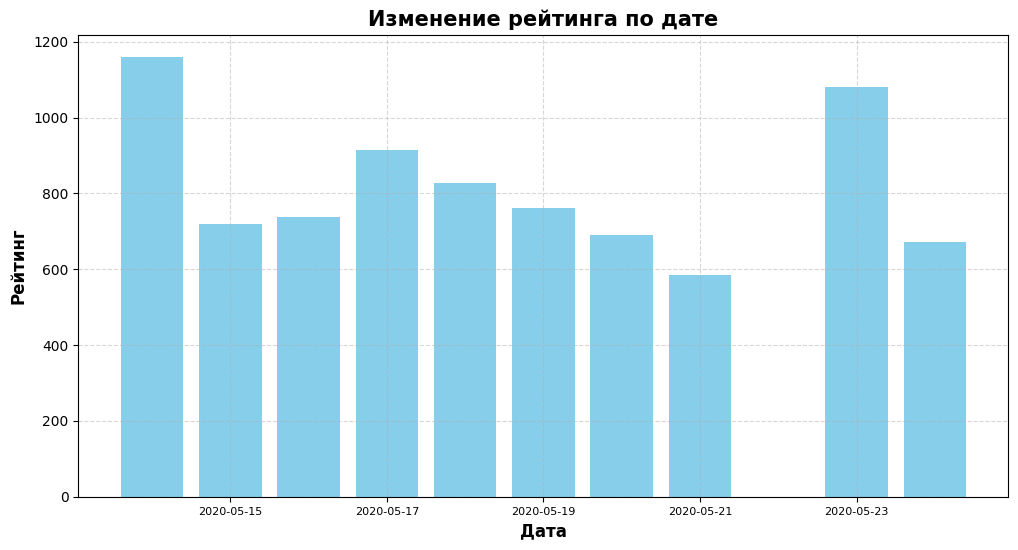

In [44]:
plt.figure(figsize=(12, 6))
plt.bar(to_vis['timestamp'], to_vis['rating'], color='skyblue')

plt.xlabel('Дата', fontsize=12, fontweight='bold')
plt.ylabel('Рейтинг', fontsize=12, fontweight='bold')
plt.xticks(fontsize=8)
plt.yticks(fontsize=10)

plt.grid(linestyle='--', alpha=0.5)

plt.title('Изменение рейтинга по дате', fontsize=15, fontweight='bold')
plt.savefig('График.pdf')

plt.show()

Сохраните график в формате pdf (так он останется векторизованным) или html (тогда останется интерактивным)

In [45]:
# сделала в верхней ячейке

### 2. Распределение студентов по курсам.

<span style="color:red">!!!ВНИМАТЕЛЬНО ИЗУЧИТЕ ТЕКСТ НИЖЕ!!!</span>.

<span style="color:orange">Если во время выполнения заданий у вас вознинут вопросы -- еще раз перечитайте текст целиком, скорее всего ответы уже содержатся в нем.</span>

Теперь вам нужно распределить студентов по осенним курсам по выбору, учитывая их предпочтения.

## 📌 **Алгоритм распределения студентов по курсам**:
1. По умолчанию на каждой дисциплине по выбору у 3 и 4 курсов может учиться 1 группа (до 30 студентов). Исключения описаны ниже. На blended-дисциплинах для четверокурсников количество мест не ограничено.
2. Проводится первая волна отбора. Для каждой дисциплины формируется список тех, кто указал её первым приоритетом (если студент должен выбрать два курса по выбору, то для него дисциплины, которые он указал первым и вторым приоритетом, рассматриваются как дисциплины первого приоритета). Если желающих больше, чем мест, то выбирается топ по перцентилю рейтинга.
3. На дисциплинах, где остались места после первой волны, формируются списки тех, кто выбрал их вторым приоритетом, и места заполняются лучшими по перцентили рейтинга студентами. После этого проводится такая же процедура для дисциплин третьего приоритета.
4. Если студент не попал на необходимое количество курсов по итогам трёх волн, с ним связывается учебный офис и решает вопрос в индивидуальном порядке.

## ☝️ **Обращаем ваше внимание на следующие детали:**

- Конкурс на каждый курс общий для 3-го и 4-го курса

- По умолчанию студент выбирает один осенний и один весенний курс по выбору, а также четверокурсники выбирают один blended-курс. Студенты групп 17-го года специализаций МОП и ТИ выбирают по 2 осенних и 2 весенних курса по выбору, также студенты групп 18' специализации МИ выбирают 2 осенних курса. <i>Для студентов, которые выбирают 2 курса (например, осенних) первый приоритет — <code>fall_1</code> и <code>fall_2</code>, второй приоритет — <code>fall_3</code>. Такие студенты участвуют только в двух волнах отбора</i>.

- Студенты специализации МОП не могут выбрать весенним курсом по выбору Машинное обучение 2. **Если студент специализации МОП выбрал Машинное обучение 2, то его приоритеты сдвигаются.** Из-за совпадений первого и второго курса по выбору двигать приоритеты не надо.

- Blended-курсы не трогайте, по ним не надо распределять, на другие курсы они никак не влияют.

- Заведомо известно, что в процессе распределения не возникнет ситуации, когда на одно место претендуют студенты с одинаковым перцентилем.

- Постарайтесь воздержаться от использования циклов там, где это возможно. <i>Допустимо итерироваться по <b>курсам</b>, на которые проводится отбор, и по <b>волнам</b> отбора. Если вы придумаете, как обойтись и без этих циклов, то на усмотрение проверяющего могут быть добавлены бонусные баллы. <b>Дублирование кода не признается успешным избавлением от циклов</b></i>

- На выходе ожидается файл res_fall.csv с результатами распределения на осенние курсы по выбору. Файл должен быть следующего формата:

    * три столбца: ID, course1, course2
    
    * Если студент не попал на курс, но должен был, то вместо названия курса в ячейке должна быть строка "???"
    
    * Если студент должен выбрать только один курс, то в колонке course2 для него должна стоять строка "-"

    * Если студент должен выбрать два курса по выбору, то порядок в колонках course1 и course2 не важен.
    
    * Формат csv: для сохранения воспользуйтесь `df.write_csv('solution.csv')`

Для работы вам могут понадобиться следующие данные:

- Результаты опроса (вы уже использовали этот файл в первой части задания, но на всякий случай ссылка: https://www.dropbox.com/s/f4rm8sjc3v99p0m/_end_seminar.xlsx?dl=0)

- Соответствие номеров групп специализациям:

    * 171, 172 - МОП; 173 - ТИ; 174 — АДИС; 175, 176 — РС; 177 — АПР
    
    * У студентов 18-го года номера групп соответствуют номерам до распределения по специализациям. Это означает, что по номеру группы 18* нельзя однозначно определить специализацию студента. При этом в рамках распределения важно знать информацию только о двух из них: МОП и МИ. Эти знание можно получить из колонок 'is_ml_student ' и 'is_mi' соответственно.

- Ограничения по количеству мест на курсах по выбору:

    * Осенние: везде 30 мест, кроме Statistical Learning Theory (60 мест), Высокопроизводительных вычислений (60 мест), Анализа неструктурированных данных ($\infty$ мест)

    * Весенние: везде 30 мест, кроме Обучения с подкреплением (60 мест), Анализа данных в бизнесе (60 мест).


Кстати, убедитесь, что в данных больше нет пропусков и повторных записей и сериализуйте датафрейм

#### 0. Проверка

Для начала давайте убедимся, что вы успешно выполнили задания первой части и проверим ваши данные на наличие пропусков и повторов:

In [46]:
df = df.collect(streaming=True)

assert df.shape[0] == 347, "В таблице остались повторы или потеряны данные"
assert df.null_count().sum_horizontal().item() == 0, "В таблице остались пропуски"

In [47]:
#df.write_csv('students.csv')

Если вы не получили AssertionError, то можете продолжать.

#### 1. [1 балл] Создайте новый признак, обозначающий, сколько осенних курсов должен выбрать студент

В этом вам может помочь информация о специализации и группе студента.

In [48]:
#df = pl.read_csv('students.csv')

In [49]:
df = df.with_columns(
        pl.when(((pl.col('17_group')).is_in(['171', '172', '173'])))
        .then(2)
        .when((pl.col('is_mi') == True) & (pl.col('18_group') != 0))
        .then(2)
        .otherwise(1)
        .alias('fall_course_n')
    )

Проверка:

In [50]:
col_name =  'fall_course_n'

ids = [
    "2662600c2c37e11e62f6ee0b88452f22",
    "d555d2805e1d93d4f023e57dc4c8f403",
    "8fe79f84f36e3a5d2d6745621321302c",
    "e4caca755ee0bdd711e18fb8084958b5",
]
assert (
    df.filter(pl.col("id").is_in(ids)).sort("id")[col_name] == [2, 1, 2, 1]
).all()

#### 2. [2 балла] Распределите студентов в соответствии с первым приоритетом

In [51]:
def first_wave_allocation(df, sem):
    '''
     Функция, которая делает первую волну распредления
     : param df: датафрейм со всей инфой по каждому студенту
     : param sem: информация о семестре (fall или spring)
     : return: датафрейм с распределением студентов по итогам первой волны
    '''
     
    # таблица, где каждому курсу соответсвует список студентов, выбравших его первым приоритетом
    prior_1 = df.group_by(pl.col(f'{sem}_1').alias('course')).agg(pl.col('id').unique())
    prior_2 = df.filter(pl.col(f'{sem}_course_n') == 2).group_by(pl.col(f'{sem}_2').alias('course')).agg(pl.col('id').unique())
    
    prior = prior_1.join(prior_2, on='course', how='full').with_columns([pl.col('id_right').fill_null([])])
    course_and_students = prior.select([
                                pl.col('course'),
                                (pl.concat_list([prior['id'], prior['id_right']])).alias('id')
                            ])

    # отбор студентов с учетом ограничения мест
    for row in course_and_students.iter_rows():
        weird_fall =  ['Statistical Learning Theory', 'Высокопроизводительные вычисления', 'Анализ неструктурированных данных']
        weird_spring = ['Обучение с подкреплением', 'Анализ данных в бизнесе']
        weird = weird_fall + weird_spring
        if row[0] not in weird:
            new_id = df.filter(pl.col('id').is_in(row[1])).sort('percentile')['id'].to_list()[:30]
        elif row[0] == 'Statistical Learning Theory' or row[0] == 'Высокопроизводительные вычисления' or row[0] in weird_spring:
            new_id = df.filter(pl.col('id').is_in(row[1])).sort('percentile')['id'].to_list()[:60]
        elif row[0] == 'Анализ неструктурированных данных':
            new_id = df.filter(pl.col('id').is_in(row[1])).sort('percentile')['id'].to_list()

        course_and_students = course_and_students.with_columns(
                                                        pl.when(pl.col('course') == row[0])
                                                          .then(pl.lit(new_id))
                                                          .otherwise(pl.col('id'))
                                                          .alias('id'))

    # таблица с инфой о том, на какие курсы смог попасть студент по итогам первой волны
    df_courses = course_and_students.explode('id').select(pl.col('id'), pl.col('course')).group_by('id').agg(pl.col('course'))
    df_courses = df_courses.with_columns([pl.when(True).then(None).alias('course1'), pl.when(True).then(None).alias('course2')])

    for row in df_courses.iter_rows():
        first = row[1][0]
        if row[0] in df.filter(pl.col(f'{sem}_course_n') == 2).select(pl.col('id'))['id'].to_list():
            second = '???'
        else:
            second = '-'
        if len(row[1]) == 2:
            second = row[1][1]
        df_courses = df_courses.with_columns([pl.when(pl.col('id') == row[0])
                                                          .then(pl.lit(first)).otherwise('course1')
                                                          .alias('course1'),
                                            pl.when(pl.col('id') == row[0])
                                                          .then(pl.lit(second)).otherwise('course2')
                                                          .alias('course2')
                                           ])

    df_courses = df_courses.select(pl.col('id'), pl.col('course1'), pl.col('course2'))

    # добавляем студентов, которые никуда не попали
    to_add = df.filter(~pl.col('id').is_in(df_courses['id'].to_list())).select([pl.col('id'),
                                                                      pl.when(True).then(pl.lit('???')).alias('course1'),
                                                                      pl.when(pl.col(f'{sem}_course_n') == 2).then(pl.lit('???')).otherwise(pl.lit('-')).alias('course2')])
    df_wave_1 = df_courses.vstack(to_add)
    
    return df_wave_1

In [52]:
df_wave_1 = first_wave_allocation(df, 'fall')
df_wave_1

id,course1,course2
str,str,str
"""bb29d9b9230528a4873f91abce2095…","""Безопасность компьютерных сист…","""-"""
"""d6c079f1ff869c8c84fa3ed30bd67e…","""Теория баз данных""","""-"""
"""f941beb89ecc5c59076bcfa7969111…","""Теория баз данных""","""Принятие решений в условиях ри…"
"""a1184a8dbbf9a7418b634339bed7e9…","""Сбор и обработка данных с помо…","""-"""
"""b739739c7080a6e15f962c38630218…","""Анализ неструктурированных дан…","""-"""
…,…,…
"""30f3653fc176d54e89ac3179c455c6…","""???""","""-"""
"""8e8d87fd686122d2c061d7b1eea2d3…","""???""","""-"""
"""8c3aa7371731bef999519c3de2c474…","""???""","""-"""


Здесь для проверки приведена таблица, в которой есть 2 дополнительные колонки:
    
    1) is_first_place - является ли студент лучшим по перцентили хотя бы на одном из курсов, куда он был зачислен
    (True / NaN)
    
    2) is_last_place  - является ли студент худшим по перцентили хотя бы на одном из курсов, куда он был зачислен (True / NaN)

In [53]:
# подгружаем инфу о перцентиле студента
df_perc = df.filter(pl.col('id').is_in(df_wave_1.select(pl.col('id'))['id'].to_list()))['id', 'percentile']

# создаем колонки с инфой о максимальном и минимальном перцентиле по каждому курсу
df_wave_1_flg = df_wave_1.join(df_perc, on='id', how='left')
df_wave_1_flg = df_wave_1_flg.with_columns([pl.when((pl.col('course1')!="-") & (pl.col('course1')!="???")).then(pl.col('percentile').max().over('course1')).otherwise(None).alias('c1_max_perc'),
                                            pl.when((pl.col('course2')!="-") & (pl.col('course2')!="???")).then(pl.col('percentile').max().over('course2')).otherwise(None).alias('c2_max_perc'),
                                            pl.when((pl.col('course1')!="-") & (pl.col('course1')!="???")).then(pl.col('percentile').min().over('course1')).otherwise(None).alias('c1_min_perc'),
                                            pl.when((pl.col('course2')!="-") & (pl.col('course2')!="???")).then(pl.col('percentile').min().over('course2')).otherwise(None).alias('c2_min_perc')])

# размечаем студентов
df_wave_1_flg = df_wave_1_flg.select(pl.col('id'),
                                     pl.col('course1'),
                                     pl.col('course2'),
                                     pl.col('percentile'),
                                     pl.when(
                                             (pl.col('percentile') == pl.col('c1_min_perc'))|
                                             (pl.col('percentile') == pl.col('c2_min_perc'))
                                     ).then(True).otherwise(None).alias('is_first_place'),
                                     pl.when(
                                             (pl.col('percentile') == pl.col('c1_max_perc'))|
                                             (pl.col('percentile') == pl.col('c2_max_perc'))
                                     ).then(True).otherwise(None).alias('is_last_place')
                                    )
df_wave_1_flg

id,course1,course2,percentile,is_first_place,is_last_place
str,str,str,f64,bool,bool
"""bb29d9b9230528a4873f91abce2095…","""Безопасность компьютерных сист…","""-""",0.036232,null,null
"""d6c079f1ff869c8c84fa3ed30bd67e…","""Теория баз данных""","""-""",0.085202,null,null
"""f941beb89ecc5c59076bcfa7969111…","""Теория баз данных""","""Принятие решений в условиях ри…",0.605381,null,true
"""a1184a8dbbf9a7418b634339bed7e9…","""Сбор и обработка данных с помо…","""-""",0.506726,null,null
"""b739739c7080a6e15f962c38630218…","""Анализ неструктурированных дан…","""-""",0.956522,null,null
…,…,…,…,…,…
"""30f3653fc176d54e89ac3179c455c6…","""???""","""-""",0.538117,null,null
"""8e8d87fd686122d2c061d7b1eea2d3…","""???""","""-""",0.253623,null,null
"""8c3aa7371731bef999519c3de2c474…","""???""","""-""",0.695652,null,null


In [54]:
check_df = pl.read_csv('_2_task_check.csv')

После распределения студентов в соответствии с первым приоритетом добавьте в свой датафрейм аналогичные признаки и запустите проверку:

In [55]:
fir_col_name =  'is_first_place'
last_col_name =  'is_last_place'

assert (
    check_df.sort("id").select("is_first_place", "is_last_place")
    == df_wave_1_flg.sort("id").select(fir_col_name, last_col_name)
).sum().rows() == [(10, 12)]

#### 3. [2 балла] Проведите все три волны отбора студентов на курсы по выбору

In [56]:
def spots_allocation_func(df_wave):
    '''
     Функция, которая определяет сколько осталось мест на курсе по итогам волны
     : param df_wave: датафрейм с инфой о распределении студентов по итогам волны
     : return: датафрейм, где по каждому курсу доступна инфа об оставшемся на нем количестве мест
    '''
     
    # список курсов и число студентов, записавшихся на них
    spots_taken = (df_wave
                .group_by('course1')
                .agg(pl.col('id').count())
                .select(pl.col('course1').alias('course'), pl.col('id').alias('places_taken'))
                .vstack(df_wave
                            .group_by('course2')
                            .agg(pl.col('id').count())
                            .select(pl.col('course2').alias('course'), pl.col('id').alias('places_taken'))
            ).group_by('course').agg(pl.col('places_taken').sum()))

    # создадим таблицу, где будет храниться информация о всех, занятых и оставшихся местах по каждому курсу
    weird =  ['Statistical Learning Theory', 'Высокопроизводительные вычисления', 'Обучение с подкреплением', 'Анализ данных в бизнесе']
    spots_allocation = spots_taken.with_columns([
                            (pl.when(pl.col('course').is_in(['-', '???'])).then(None)
                              .when(pl.col('course').is_in(['Анализ неструктурированных данных'])).then(1000)
                              .when(pl.col('course').is_in(weird)).then(60)
                              .otherwise(30)).alias('all_places')
                        ]).select(pl.col('course'), pl.col('all_places'), pl.col('places_taken'), (pl.col('all_places') - pl.col('places_taken')).alias('places_left'))
    return spots_allocation            

In [57]:
def second_wave_allocation(df_wave_1, df, sem):
    
    '''
     Функция, которая делает вторую волну распредления
     : param df_wave_1: датафрейм с распределением первой волны
     : param df: датафрейм со всей инфой по каждому студенту
     : param sem: информация о семестре (fall или spring)
     : return: датафрейм с распределением студентов по итогам второй волны
    '''
     
          
    # кейс 1: студент должен выбрать 1 курс, но не прошел => course1='???', course2='-'
    ids_1 = df_wave_1.filter((pl.col('course1') == '???') & (pl.col('course2') == '-'))['id']
    case_1 = df.filter(pl.col('id').is_in(ids_1)).group_by(f'{sem}_2').agg(pl.col('id'))

    # кейс 2: студент должен выбрать 2 курса, на один прошел, а на другой нет => course1=что-то, course2='???'
    if sem == 'fall':
        bad_people = df.filter(pl.col(f'{sem}_1') == pl.col(f'{sem}_2'))['id'].to_list()
        ids_2 = df_wave_1.filter(~pl.col('course1').is_in(['???', '-']) & (pl.col('course2') == '???')).filter(~pl.col('id').is_in(bad_people))['id']
    else:
        ids_2 = df_wave_1.filter(~pl.col('course1').is_in(['???', '-']) & (pl.col('course2') == '???'))['id']
    case_2 = df.filter(pl.col('id').is_in(ids_2)).group_by(f'{sem}_3').agg(pl.col('id'))

    # кейс 3: студент должен выбрать 2 курса, на ни на один не прошел => course1='???', course2='???'
    ids_3 = df_wave_1.filter((pl.col('course1') == '???') & (pl.col('course2') == '???'))['id']
    case_3 = df.filter(pl.col('id').is_in(ids_3)).group_by(f'{sem}_3').agg(pl.col('id').alias('id_right_right'))

    # соединяем
    case = case_1.join(case_2, left_on=f'{sem}_2', right_on=f'{sem}_3', how='full').join(case_3, on=f'{sem}_3', how='full').select(
                                                                            pl.when(pl.col(f'{sem}_2').is_not_null())
                                                                              .then(pl.col(f'{sem}_2'))
                                                                              .otherwise(pl.col(f'{sem}_3')).alias('course'),
                                                                            pl.col('id'),
                                                                            pl.col('id_right'),
                                                                            pl.col('id_right_right')
                                                                ).fill_null([''])
    course_and_students = case.select([
                                        pl.col('course'),
                                        (pl.concat_list([case['id'], case['id_right'], case['id_right_right']])).alias('id')
                                    ])

    # отбор студентов с учетом ограничения мест
    spots_allocation = spots_allocation_func(df_wave_1)
    for row in course_and_students.iter_rows():
        i = spots_allocation['course', 'places_left'].filter(pl.col('course') == f'{row[0]}')['places_left'][0]
        new_id = df.filter(pl.col('id').is_in(row[1])).sort('percentile')['id'].to_list()[:i]
        course_and_students = course_and_students.with_columns(
                                                        pl.when(pl.col('course') == row[0])
                                                          .then(pl.lit(new_id))
                                                          .otherwise(pl.col('id'))
                                                          .alias('id'))

    # айди студента и инфа о курсе, на который он попал
    allocated_students = course_and_students.explode('id').filter(pl.col('id').is_not_null())['id', 'course']

    # обновляем инфу о студентах распредленных после первой волны
    df_wave_2 = df_wave_1.join(allocated_students, on='id', how='left').select([
                                                    pl.col('id'),
                                                    # кейс 1
                                                    pl.when((pl.col('id').is_in(ids_1)) & pl.col('course').is_not_null()).then(pl.col('course')).otherwise(pl.col('course1')).alias('course1'),
                                                    # кейс 2 и кейс 3
                                                    (pl.when((pl.col('id').is_in(ids_2)) & (pl.col('course').is_not_null())).then(pl.col('course'))
                                                      .when((pl.col('id').is_in(ids_3)) & (pl.col('course').is_not_null())).then(pl.col('course'))
                                                      .otherwise(pl.col('course2'))).alias('course2')
                                                ])
    return df_wave_2      

In [58]:
df_wave_2 = second_wave_allocation(df_wave_1, df, 'fall')
df_wave_2

id,course1,course2
str,str,str
"""bb29d9b9230528a4873f91abce2095…","""Безопасность компьютерных сист…","""-"""
"""d6c079f1ff869c8c84fa3ed30bd67e…","""Теория баз данных""","""-"""
"""f941beb89ecc5c59076bcfa7969111…","""Теория баз данных""","""Принятие решений в условиях ри…"
"""a1184a8dbbf9a7418b634339bed7e9…","""Сбор и обработка данных с помо…","""-"""
"""b739739c7080a6e15f962c38630218…","""Анализ неструктурированных дан…","""-"""
…,…,…
"""30f3653fc176d54e89ac3179c455c6…","""Матричные вычисления""","""-"""
"""8e8d87fd686122d2c061d7b1eea2d3…","""Высокопроизводительные вычисле…","""-"""
"""8c3aa7371731bef999519c3de2c474…","""???""","""-"""


In [59]:
def third_wave_allocation(df_wave_2, df, sem):
    
    '''
     Функция, которая делает третью волну распредления
     : param df_wave_2: датафрейм с распределением второй волны
     : param df: датафрейм со всей инфой по каждому студенту
     : param sem: информация о семестре (fall или spring)
     : return: датафрейм с распределением студентов по итогам третьей волны
    '''
     
       
    # во время третьей волны возможен лишь один кейс: студент должен был выбрать 1 курс, но не прошел ни в одной из предыдщих волн => course1='???', course2='-'
    ids_1 = df_wave_2.filter((pl.col('course1') == '???') & (pl.col('course2') == '-'))['id'].to_list()
    case = df.filter(pl.col('id').is_in(ids_1)).group_by(f'{sem}_3').agg(pl.col('id')).select(pl.col(f'{sem}_3').alias('course'), pl.col('id'))

    # отбор студентов с учетом ограничения мест
    spots_allocation = spots_allocation_func(df_wave_2)
    for row in case.iter_rows():
        i = spots_allocation['course', 'places_left'].filter(pl.col('course') == f'{row[0]}')['places_left'][0]
        new_id = df.filter(pl.col('id').is_in(row[1])).sort('percentile')['id'].to_list()[:i]
        case = case.with_columns(
                                pl.when(pl.col('course') == row[0])
                                  .then(pl.lit(new_id))
                                  .otherwise(pl.col('id'))
                                  .alias('id'))

    # айди студента и инфа о курсе, на который он попал
    allocated_students = case.explode('id').filter(pl.col('id').is_not_null())['id', 'course']

    # обновляем инфу о студентах распредленных после второй волны
    df_wave_3 = df_wave_2.join(allocated_students, on='id', how='left').select([
                                                    pl.col('id').alias('ID'),
                                                    # кейс 1
                                                    pl.when((pl.col('id').is_in(ids_1)) & pl.col('course').is_not_null()).then(pl.col('course')).otherwise(pl.col('course1')).alias('course1'),
                                                    pl.when(pl.col('course2') == pl.col('course1')).then(pl.lit("???")).otherwise(pl.col('course2')).alias('course2')
                                                ])
    return df_wave_3

In [60]:
df_wave_3 = third_wave_allocation(df_wave_2, df, 'fall')
df_wave_3

ID,course1,course2
str,str,str
"""bb29d9b9230528a4873f91abce2095…","""Безопасность компьютерных сист…","""-"""
"""d6c079f1ff869c8c84fa3ed30bd67e…","""Теория баз данных""","""-"""
"""f941beb89ecc5c59076bcfa7969111…","""Теория баз данных""","""Принятие решений в условиях ри…"
"""a1184a8dbbf9a7418b634339bed7e9…","""Сбор и обработка данных с помо…","""-"""
"""b739739c7080a6e15f962c38630218…","""Анализ неструктурированных дан…","""-"""
…,…,…
"""30f3653fc176d54e89ac3179c455c6…","""Матричные вычисления""","""-"""
"""8e8d87fd686122d2c061d7b1eea2d3…","""Высокопроизводительные вычисле…","""-"""
"""8c3aa7371731bef999519c3de2c474…","""Анализ неструктурированных дан…","""-"""


**Отправьте свой файл res_fall.csv в контест (будет в ближайшее время, следите за новостями) и прикрепите/укажите ниже ваш никнейм и ссылку на успешную посылку.**

In [61]:
df_wave_3.write_csv('res_fall.csv')

Никнейм (участник) : Салман Ясмина

Успешная попытка (ID) : 120346088

Ссылка: https://contest.yandex.ru/contest/68637/run-report/120346088/

(Я там потом еще отправляла, после того, как немного - жоско сильно - почистила код, чтобы проверить, что ничего не сломалось)

*Дисклеймер:*

Контест выдаётся для самопроверки. Если ваша посылка получила ОК, то код, скорее всего, правильный. Но при этом оценка всё равно может быть снижена в случае обнаружения неэффективностей или ошибок в коде. Если вы сдадите в AnyTask очевидно неработающий код или ноутбук без кода, но при этом в контест будет сдан корректный файл, то это будет расцениваться как плагиат.

На всякий случай просим вас сдать вместе с ноутбуком файл res_fall.csv в anytask

<a href="https://ibb.org.ru/1/fRW93r"><img src="https://ibb.org.ru/images/2024/10/11/ZAGRUZENNOE.jpg" alt="ZAGRUZENNOE.jpg" border="0"></a>

### 4. [1 балл] Распределите таким же образом студентов еще и на весенние курсы по выбору.

Если ваш код был хорошо структурирован, то это не составит проблем.

Если вы выполнили это задание, сдайте среди прочего файл res_spring.csv в таком же формате, как и res_fall.csv.

In [62]:
# разметим МОП cтудентов, которые записались на Машинное обучение 2
flagged_df = df.with_columns([
    pl.when(pl.col("is_ml_student") & (pl.col("spring_1") == "Машинное обучение 2"))
      .then(pl.lit("???"))
      .otherwise(pl.col("spring_1")).alias("spring_1"),

    pl.when(pl.col("is_ml_student") & (pl.col("spring_2") == "Машинное обучение 2"))
      .then(pl.lit("???"))
      .otherwise(pl.col("spring_2")).alias("spring_2"),

    pl.when(pl.col("is_ml_student") & (pl.col("spring_3") == "Машинное обучение 2"))
      .then(pl.lit("???"))
      .otherwise(pl.col("spring_3")).alias("spring_3")
])

# смещаем приоритеты
df_spring = flagged_df.with_columns([
                pl.when((pl.col("spring_1") == "???") & (pl.col("spring_2") != "???"))
                  .then(pl.col("spring_2"))
                  .when((pl.col("spring_1") == "???") & (pl.col("spring_2") == "???"))
                  .then(pl.col("spring_3"))
                  .otherwise(pl.col("spring_1")).alias("spring_1"),

                pl.when((pl.col("spring_2") == "???") & (pl.col("spring_1") != "???"))
                  .then(pl.col("spring_3"))
                  .when((pl.col("spring_2") == "???") & (pl.col("spring_1") == "???"))
                  .then(pl.col("spring_2"))
                  .when((pl.col("spring_2") != "???") & (pl.col("spring_1") == "???"))
                  .then(pl.col("spring_3"))
                  .otherwise(pl.col("spring_2")).alias("spring_2"),

                pl.when((pl.col("spring_2") == "???") | (pl.col("spring_1") == "???"))
                  .then(pl.lit("???"))
                  .otherwise(pl.col("spring_3")).alias("spring_3")

            ])

# количество курсов, которые должен был брать студент
df_spring = df_spring.with_columns(
        pl.when(((pl.col('17_group')).is_in(['171', '172', '173'])))
        .then(2)
        .otherwise(1)
        .alias('spring_course_n')
    )
df_spring.head()

timestamp,id,fall_1,fall_2,fall_3,spring_1,spring_2,spring_3,is_first_time,17_group,blended,rating,18_group,is_mi,percentile,is_ml_student,resp_n,fall_course_n,spring_course_n
str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,f64,bool,i64,i32,i32
"""2020-05-24 01:23:31""","""9d19b0d5f4fc8d7edc2258406f872c…","""Безопасность компьютерных сист…","""Язык SQL""","""Высокопроизводительные вычисле…","""Компьютерные сети""","""Дискретная оптимизация""","""Численные методы""","""""","""""","""""",695,188,0,0.197309,false,0,1,1
"""2020-05-24 01:21:31""","""04bcb5c9d23813ffa940e1febb27fa…","""Теория баз данных""","""Высокопроизводительные вычисле…","""Безопасность компьютерных сист…","""Компьютерные сети""","""Дискретная оптимизация""","""Машинное обучение 2""","""Нет""","""""","""""",646,186,0,0.430493,false,0,1,1
"""2020-05-23 21:16:40""","""79d14db48e4737af731960ae212d51…","""Безопасность компьютерных сист…","""Принятие решений в условиях ри…","""Анализ неструктурированных дан…","""Проектирование и разработка вы…","""Методы сжатия и передачи медиа…","""Компьютерное зрение""","""Да""","""172""","""DevOps""",966,0,0,0.985507,false,0,2,2
"""2020-05-23 21:16:40""","""f2d210ace25a841e1e58036b257d5d…","""Анализ неструктурированных дан…","""Моделирование временных рядов""","""Высокопроизводительные вычисле…","""Обучение с подкреплением""","""Компьютерное зрение""","""Методы сжатия и передачи медиа…","""""","""176""","""Соревновательный анализ данных""",1195,0,0,0.369565,false,0,1,1
"""2020-05-21 16:33:15""","""1341f488fae5f1ccf164960fd6506c…","""Язык SQL""","""Теория баз данных""","""Безопасность компьютерных сист…","""Промышленное программирование …","""Компьютерные сети""","""Системы баз данных""","""Да""","""""","""""",584,188,0,0.721973,false,0,1,1


In [63]:
df_wave_1 = first_wave_allocation(df_spring, 'spring')
df_wave_2 = second_wave_allocation(df_wave_1, df_spring, 'spring')
df_wave_3 = third_wave_allocation(df_wave_2, df_spring, 'spring')
df_wave_3

ID,course1,course2
str,str,str
"""ffc58d371e2f52e1c7f45d49d3d629…","""Системы баз данных""","""-"""
"""0f114e98d9f732aa51db34f687db26…","""Дискретная оптимизация""","""-"""
"""9abd31fe9761b5abd56524915237c1…","""Дополнительные главы прикладно…","""-"""
"""f736e00dc03850c59649e77149895d…","""Машинное обучение 2""","""-"""
"""8a1162ce3c94d8974210a24f4b4f5f…","""Промышленное программирование …","""-"""
…,…,…
"""d0d8ff53ed5b119f9056068e954256…","""Численные методы""","""-"""
"""496ea4f0d4abe264b1bb1b80eb3830…","""Численные методы""","""-"""
"""8c3aa7371731bef999519c3de2c474…","""Методы сжатия и передачи медиа…","""-"""


In [64]:
df_wave_3.write_csv('res_spring.csv')

**Отправьте свой файл res_spring.csv в контест (будет в ближайшее время, следите за новостями) и прикрепите/укажите ниже ваш никнейм и ссылку на успешную посылку.**

Никнейм: Салман Ясмина

Номер удачной попытки: 120599427

Ссылка на удачную попытку: https://contest.yandex.ru/contest/68637/run-report/120599427/

На всякий случай просим вас сдать вместе с ноутбуком файл res_spring.csv в anytask

Вставьте картинку, описывающую ваш опыт выполнения этого задания:

<a href="https://ibb.org.ru/1/fRWYwC"><img src="https://ibb.org.ru/images/2024/10/11/Crying-homework-sponge-on-lol.jpg" alt="Crying-homework-sponge-on-lol.jpg" border="0"></a>